In [26]:
import pandas as pd
import re
import plotly.express as px
from tqdm import tqdm
from joblib import Parallel, delayed
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch 
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

In [164]:
import warnings
warnings.filterwarnings("ignore")

In [27]:
df = pd.read_csv("linkedin_jobs.csv")
df.head()

,Title,Company,Location,Link,Description,Responsibilities,QualificationsRequired,QualificationsPreferred,Requirements,Salary,EmploymentType,AboutTheCompany,WorkplaceType,Applicants,Posted_date
0,Robotics & Automation Intern - Undergraduate,Los Alamos National Laboratory,"Los Alamos, NM",https://www.linkedin.com/jobs/view/4301581600/...,What You Will Do\n\nAre you passionate about e...,['Are you passionate about engineering and eag...,[],[],[],$31/hr,Full Time,"Los Alamos National Laboratory\n169,402 follow...",On-site,16 people clicked apply,2025/09/19
1,"Intern, R&D Undergraduate Year-Round - Monitor...",Sandia National Laboratories,"Albuquerque, NM",https://www.linkedin.com/jobs/view/4301356549/...,What Your Job Will Be Like\n\nThe Monitoring S...,[],['You bring the confidence and skills to be el...,[],[],"$5,000/month",Full Time,"Sandia National Laboratories\n159,269 follower...",Remote,3 people clicked apply,2025/09/19
2,Summer Internship 2026 - Computer Science | Da...,Denver Water,"Denver, CO",https://www.linkedin.com/jobs/view/4301344142/...,Denver Water Internships\n\nInternship Opportu...,[],['quality water and promotes its efficient use...,[],[],$20/hr,Internship,"Denver Water\n12,834 followers\nFollow\nUtilit...",Remote,93 people clicked apply,2025/09/19
3,Quantum Computing Algorithms Intern,Thermo Fisher Scientific,"Frederick, MD",https://www.linkedin.com/jobs/view/4301980127/...,This job is sourced from a job board. Learn Mo...,[],"['Fri)', 'leading brands, including Thermo Sci...",[],[],$22.50/hr,Intern,"Thermo Fisher Scientific\n50,703 followers\nFo...",On-site,0 people clicked apply,2025/09/20
4,R&D Engineering Intern - Summer 2026,Lensa,"Fort Worth, TX",https://www.linkedin.com/jobs/view/4302051558/...,Lensa is a career site that helps job seekers ...,[],[],"['A minimum 3.0 out of a 4.0 cumulative GPA', ...",['we want you to keep growing. With our expand...,$26.50 - $45.25 per hour,Full Time,"Lensa\n151,035 followers\nFollow\nInternet Pub...",Remote,2 people clicked apply,2025/09/20


## Salary

In [12]:
def parse_salary(s):
    """
    Parse salary string into an estimated annual salary (numeric).
    Handles hourly, weekly, monthly, yearly, and ranges.
    Assumptions:
    - Hourly: 40 hrs/week, 52 weeks/year
    - Weekly: 52 weeks/year
    - Monthly: 12 months/year
    """
    if not isinstance(s, str) or not s.strip():
        return np.nan
    
    s = s.lower().replace(",", "").strip()

    # Extract numbers (with optional K or M)
    nums = re.findall(r"\$?\d+(?:\.\d+)?[kKmM]?", s)
    if not nums:
        return np.nan
    
    # Convert numbers into floats
    values = []
    for n in nums:
        n = n.replace("$", "")
        if "k" in n:
            values.append(float(n[:-1]) * 1000)
        elif "m" in n:
            values.append(float(n[:-1]) * 1_000_000)
        else:
            values.append(float(n))
    
    # If it's a range, take the average
    val = sum(values) / len(values)

    # Detect time unit
    if re.search(r"/?\s*hour|/hr", s):
        val *= 40 * 52
    elif re.search(r"/?\s*week|/wk", s):
        val *= 52
    elif re.search(r"/?\s*month|/mo", s):
        val *= 12
    elif re.search(r"/?\s*year|/yr|/y", s):
        pass  # already annual
    else:
        # No explicit unit → assume yearly
        pass

    return val

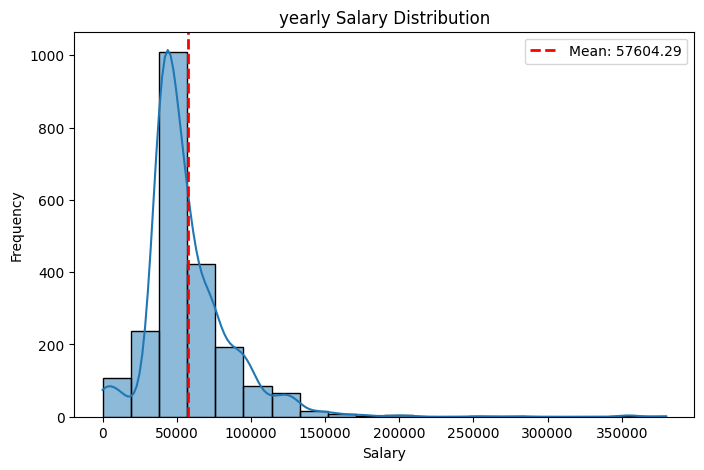

In [13]:
df["Salary"] = df["Salary"].apply(parse_salary)
salary_mean = df["Salary"].mean()

plt.figure(figsize=(8, 5))
sns.histplot(df["Salary"], bins=20, kde=True)
plt.axvline(salary_mean, color='red', linestyle='dashed', linewidth=2, label=f"Mean: {salary_mean:.2f}")
plt.title("yearly Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Seniority

In [28]:
def normalize_title(title):
    """
    Normalize a job title into a standard seniority level based on LinkedIn-style patterns.
    """
    if not isinstance(title, str):
        return "Unknown"

    t = title.lower().strip()

    if "intern" in t or "internship" in t:
        return "Intern"
    if any(x in t for x in ["chief", "vp", "vice president", "head of", "executive", "cto", "ceo", "cfo"]):
        return "Executive"
    if any(x in t for x in ["manager", "supervisor", "team lead", "project lead", "product lead", "director"]):
        return "Management"
    if any(x in t for x in ["lead", "principal", "staff", "architect", "expert"]):
        return "Lead/Principal"
    if "senior" in t or "sr." in t or "sr " in t:
        return "Senior"
    if re.search(r"\b(ii|2|level 2|l2|mid)\b", t) or "associate" in t or "experienced" in t:
        return "Mid"
    if any(x in t for x in ["junior", "jr", "entry"]) or re.search(r"\b(i|1|level 1|l1)\b", t):
        return "Entry"
    if re.search(r"\b(iii|3|level 3|l3)\b", t):
        return "Senior"
    if re.search(r"\b(iv|4|level 4|l4)\b", t):
        return "Lead/Principal"
    if re.search(r"\b(v|5|level 5|l5)\b", t):
        return "Management"
    if "specialist" in t:
        return "Mid"
    if "consultant" in t:
        return "Mid"
    if "analyst" in t:
        return "Entry" if any(x in t for x in ["junior", "jr", "entry"]) else "Mid"
    if "technician" in t:
        return "Entry" if "assistant" in t or "junior" in t else "Mid"
    if "coordinator" in t:
        return "Entry"
        
    return "Entry"


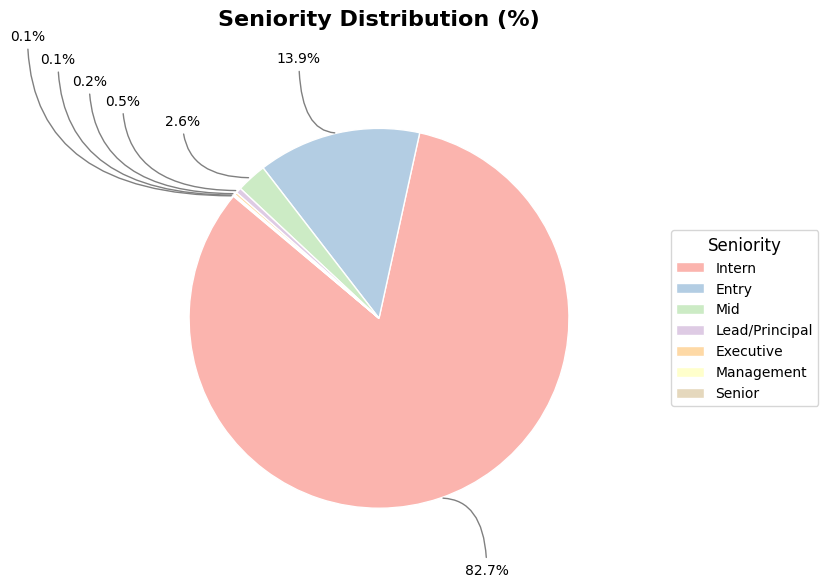

In [60]:
df["seniority"] = df["Title"].apply(normalize_title)
seniority_counts = df["seniority"].value_counts(normalize=True) * 100

labels = seniority_counts.index
sizes = seniority_counts.values
colors = plt.cm.Pastel1.colors

offset_factors = {
    "Lead/Principal": 1.7,
    "Executive": 1.9,
    "Management": 2.1,
    "Senior": 2.3
}

fig, ax = plt.subplots(figsize=(9, 9))

wedges, _ = ax.pie(
    sizes,
    startangle=140,
    colors=colors,
    wedgeprops=dict(edgecolor='white'),
    radius=1.0
)

# Add percentage labels with straight callout lines
for i, wedge in enumerate(wedges):
    label = labels[i]
    size = sizes[i]

    angle = (wedge.theta2 + wedge.theta1) / 2
    angle_rad = np.deg2rad(angle)
    x = np.cos(angle_rad)
    y = np.sin(angle_rad)

    offset = offset_factors.get(label, 1.4)
    label_x = offset * x
    label_y = offset * y

    ha = "left" if x > 0 else "right"

    ax.annotate(
        f"{100 * size / sum(sizes):.1f}%",
        xy=(x, y),                         
        xytext=(label_x, label_y),        
        ha=ha,
        va='center',
        fontsize=10,
        arrowprops=dict(
            arrowstyle="-",
            connectionstyle="angle3",   
            color="gray"
        )
    )

ax.legend(
    wedges,
    labels,
    title="Seniority",
    loc="center left",
    bbox_to_anchor=(1.1, 0.5),
    fontsize=10,
    title_fontsize=12
)

ax.set_title("Seniority Distribution (%)", fontsize=16, fontweight="bold")
plt.title("Seniority Distribution (%)", fontsize=16, fontweight="bold", pad=40)
plt.tight_layout()
plt.show()

## Domain

In [47]:
Model_ID = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(Model_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    Model_ID,
    dtype=torch.float16,   
    device_map="auto"
)

Loading checkpoint shards: 100%|██████████| 4/4 [00:39<00:00,  9.95s/it]


In [109]:
def generate_domains_batched(df, title_column="Title", batch_size=16, max_new_tokens=15):
    all_domains = []

    for i in tqdm(range(0, len(df), batch_size), desc="Batch extracting domains"):
        batch_df = df.iloc[i:i + batch_size]

        prompts = [
    f"""
Classify the following job title into a general professional domain (e.g., Data Science, Cybersecurity, Software Engineering, etc.).

Return only the domain name, no explanations or punctuation.

Job Title: {title}
Domain:
"""
    for title in batch_df[title_column]
]


        encodings = tokenizer(
            prompts, return_tensors="pt", padding=True, truncation=True, max_length=4096
        )
        input_ids = encodings["input_ids"].to(model.device)
        attention_mask = encodings["attention_mask"].to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=0.0,
                pad_token_id=tokenizer.pad_token_id
            )

        for j in range(outputs.shape[0]):
            gen_tokens = outputs[j][input_ids.shape[1]:] 
            text = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()
            domain = text.split("\n")[0].strip()
            all_domains.append(domain)

    assert len(all_domains) == len(df), f"Expected {len(df)} results, got {len(all_domains)}"
    return all_domains

In [110]:
# We use the LLM to assign first 500 rows with domain labels from the title

domain_labels = generate_domains_batched(df.iloc[:500], title_column="Title")
df["Job Category"] = pd.Series(domain_labels).reindex(df.index)

Batch extracting domains: 100%|██████████| 32/32 [00:28<00:00,  1.11it/s]


In [116]:
normalized_labels = {
    'Software Engineering': 'Software Engineering',
    'Data Science': 'Data Science',
    'Data Entry': 'Data Science',
    'Business Analysis': 'Data Science',

    'Artificial Intelligence/Machine Learning': 'Artificial Intelligence',
    'Artificial Intelligence': 'Artificial Intelligence',
    'AI Science': 'Artificial Intelligence',

    'Bioinformatics': 'Biomedical Sciences',
    'Biomedical Research': 'Biomedical Sciences',
    'Biomedical Engineering': 'Biomedical Sciences',
    'Life Sciences': 'Biomedical Sciences',

    'Research and Development': 'R&D',
    'Research': 'R&D',

    'Mechanical Engineering': 'Engineering',
    'Electrical Engineering': 'Engineering',
    'Materials Engineering': 'Engineering',
    'Nuclear Engineering': 'Engineering',
    'Network Engineering': 'Engineering',
    'Engineering': 'Engineering',
    'Robotics Engineering': 'Engineering',
    'Robotics and Automation': 'Engineering',
    'Manufacturing Engineering': 'Engineering',

    'Environmental Consulting': 'Environmental Sciences',
    'Environmental Sciences': 'Environmental Sciences',
    'Environmental Services': 'Environmental Sciences',
    'Natural Resources': 'Environmental Sciences',

    'Cybersecurity': 'Cybersecurity',
    'Information Security': 'Cybersecurity',

    'Healthcare': 'Healthcare',
    'Medical Device Engineering': 'Healthcare',
    'Medical Affairs': 'Healthcare',
    'Anesthesiology': 'Healthcare',

    'Business Strategy': 'Business',
    'Government and Public Affairs': 'Business',

    'User Experience Research': 'UX/UI Design',
    'User Experience Design': 'UX/UI Design',

    'Information Technology': 'Information Technology',
    'IT Support': 'Information Technology',

    'Quality Assurance': 'Quality and Safety',
    'Quality Engineering': 'Quality and Safety',
    'Safety': 'Quality and Safety',

    'Quantum Computing': 'Other',
    'Laboratory Technician': 'Other',
    'Airline Industry': 'Other'
}

df["Job Category"] = df["Job Category"].replace(normalize_dict)

## Model Selection

In [120]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Dataset prepration
df_train_test = df.iloc[:500]

# We need to transfer the text into vector representation for machine learning models
vectorizer = TfidfVectorizer()
label_encoder = LabelEncoder()
feature = vectorizer.fit_transform(df_train_test["Title"])
label = label_encoder.fit_transform(df_train_test["Job Category"])

x_train, x_test, y_train, y_test = train_test_split(
    feature,
    label,
    test_size=0.2,    
    random_state=42       
)

In [172]:
# Train model and do hyperparameter tuning to figure out the best model 
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

def evaluate_models_with_tuning(x_train, x_test, y_train, y_test):
    models = {
        "Naive Bayes": (
            MultinomialNB(),
            {"alpha": [0.1, 1.0, 5.0]}
        ),
        "Random Forest": (
            RandomForestClassifier(),
            {"n_estimators": [50, 100, 200, 300], "max_depth": [None, 10, 20]}
        ),
        "Decision Tree": (
            DecisionTreeClassifier(),
            {"max_depth": [None, 5, 10, 20], "criterion": ["gini", "entropy"]}
        ),
        "Linear SVC": (
            LinearSVC(max_iter=5000),
            {"C": [0.1, 1, 10]}
        ),
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, solver="saga"),
            {"C": [0.1, 1, 10, 20]}
        )
    }

    results = []
    best_model = None
    best_accuracy = 0.0

    for name, (model, param_grid) in models.items():
        grid = GridSearchCV(
            model,
            param_grid,
            cv=5,
            scoring="accuracy",
            n_jobs=-1
        )
        grid.fit(x_train, y_train)

        best_estimator = grid.best_estimator_
        y_pred = best_estimator.predict(x_test)
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "Model": name,
            "Test Accuracy": acc,
            "Best Params": grid.best_params_,
            "Estimator": best_estimator
        })

        if acc > best_accuracy:
            best_accuracy = acc
            best_model = best_estimator

    results_df = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
    return results_df.drop(columns=["Estimator"]), best_model

In [173]:
results_df, best_model = evaluate_models_with_tuning(x_train, x_test, y_train, y_test)
results_df

,Model,Test Accuracy,Best Params
0,Random Forest,0.80,"{'max_depth': None, 'n_estimators': 200}"
1,Naive Bayes,0.79,{'alpha': 0.1}
2,Linear SVC,0.79,{'C': 1}
3,Logistic Regression,0.79,{'C': 10}
4,Decision Tree,0.75,"{'criterion': 'gini', 'max_depth': 10}"


In [174]:
# We choose Random Forest Classification 

df_unlabeled = df.iloc[500:]

X_unlabeled = vectorizer.transform(df_unlabeled["Title"])
y_pred_unlabeled = best_model.predict(X_unlabeled)
y_pred_labels = label_encoder.inverse_transform(y_pred_unlabeled)

df.loc[500:, "Job Category"] = y_pred_labels

In [175]:
df.tail()

,Title,Company,Location,Link,Description,Responsibilities,QualificationsRequired,QualificationsPreferred,Requirements,Salary,EmploymentType,AboutTheCompany,WorkplaceType,Applicants,Posted_date,seniority,Job Category
3573,Manufacturing Data Analytics Intern,JLG Industries,"McConnellsburg, PA",https://www.linkedin.com/jobs/view/4297036518/...,"About JLG, An Oshkosh Company\n\nJLG began in ...",[],['Student working towards a Bachelor’s degree ...,[],[],$18/hr,Full Time,NaN,On-site,27 people clicked apply,2025/09/13,Intern,Data Science
3574,Cloud Database Specialist,DMI,NaN,https://www.linkedin.com/jobs/view/4244835498/...,DMI is a leading provider of digital services ...,[],['The Cloud Database Specialist III must posse...,[],"['Required And Desired Skills/Certifications',...",NaN,Full Time,NaN,Remote,NaN,NaN,Mid,Software Engineering
3575,Data Migration & Integration Specialist,Celerity,"Walnut Creek, CA",https://www.linkedin.com/jobs/view/4302254613/...,Title: Data Migration & Integration Specialist...,[],[],"['Industry experience in Utilities (Electric, ...","['5+ years of hands', 'on experience in data m...",$48/hr,Full Time,NaN,Remote,17 applicants,2025/09/20,Mid,Data Science
3576,Data Intern,Erie Insurance Group,"Erie, PA",https://www.linkedin.com/jobs/view/4297904128/...,Division Or Field Office\n\nClaims Division\n\...,['Erie Insurance offers interns the opportunit...,"['Minimum Educational Requirements', 'High sch...",[],[],$20/hr,Full Time,NaN,On-site,81 people clicked apply,2025/09/13,Intern,Data Science
3577,Head of Enterprise Data Office Operations,U.S. Bank,"Cincinnati, OH",https://www.linkedin.com/jobs/view/4301719438/...,"At U.S. Bank, we’re on a journey to do our bes...",[],['Bachelor’s or Master’s degree in Computer Sc...,['Lead with examples and be able to roll up sl...,[],$193K/yr,Full Time,NaN,Hybrid,10 people clicked apply,2025/09/19,Executive,Data Science


## Job Domain Count

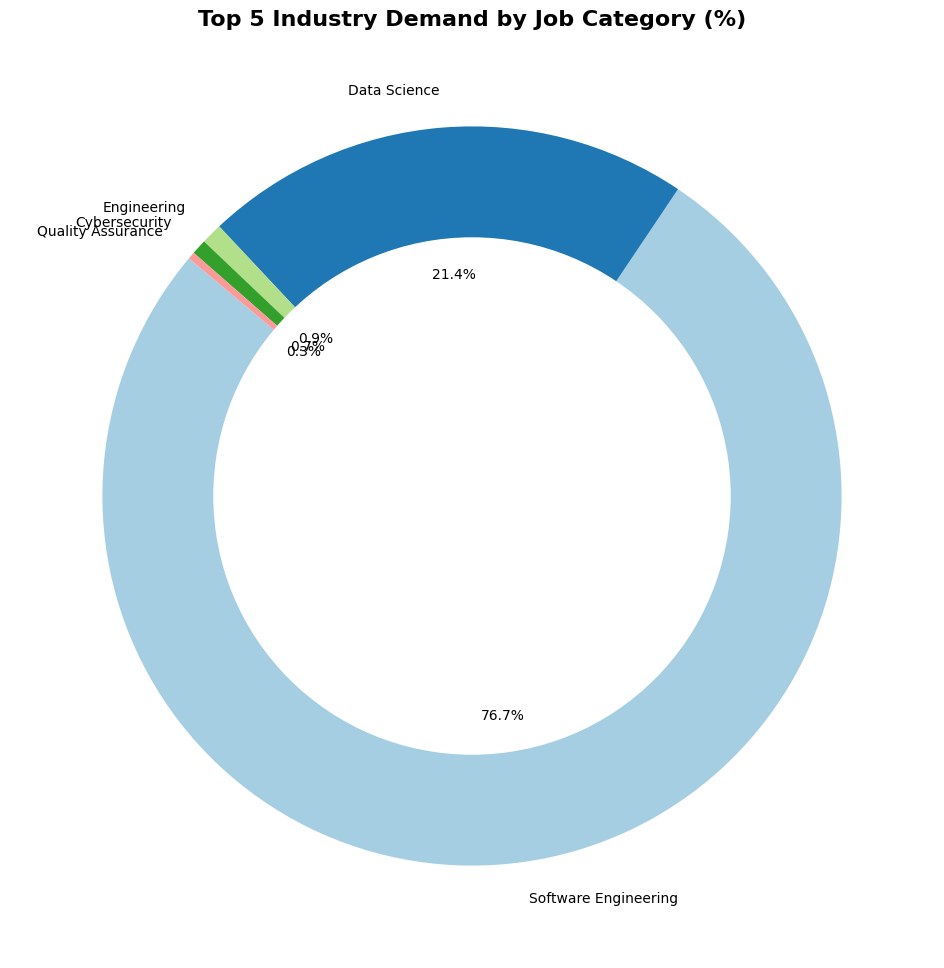

In [177]:
category_counts = df["Job Category"].value_counts().nlargest(5)
category_percentages = (category_counts / category_counts.sum()) * 100

plt.figure(figsize=(12, 12))
plt.pie(
    category_percentages,
    labels=category_percentages.index,
    autopct="%.1f%%",
    startangle=140,
    colors=plt.cm.Paired.colors
)

centre_circle = plt.Circle((0, 0), 0.70, fc="white")
plt.gca().add_artist(centre_circle)
plt.title("Top 5 Industry Demand by Job Category (%)", fontsize=16, fontweight="bold")
plt.show()

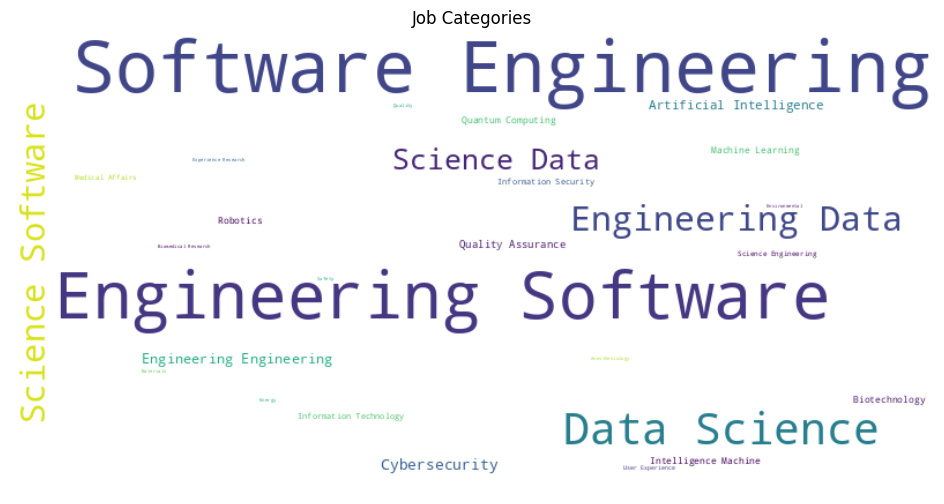

In [178]:
from wordcloud import WordCloud

text = " ".join(df["Job Category"].dropna().astype(str))

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis" 
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Job Categories")
plt.show()

## Location and Time

In [179]:
US_STATE_MAP = {
    "Alabama": "AL","Alaska": "AK","Arizona": "AZ","Arkansas": "AR","California": "CA",
    "Colorado": "CO","Connecticut": "CT","Delaware": "DE","Florida": "FL","Georgia": "GA",
    "Hawaii": "HI","Idaho": "ID","Illinois": "IL","Indiana": "IN","Iowa": "IA",
    "Kansas": "KS","Kentucky": "KY","Louisiana": "LA","Maine": "ME","Maryland": "MD",
    "Massachusetts": "MA","Michigan": "MI","Minnesota": "MN","Mississippi": "MS",
    "Missouri": "MO","Montana": "MT","Nebraska": "NE","Nevada": "NV","New Hampshire": "NH",
    "New Jersey": "NJ","New Mexico": "NM","New York": "NY","North Carolina": "NC",
    "North Dakota": "ND","Ohio": "OH","Oklahoma": "OK","Oregon": "OR","Pennsylvania": "PA",
    "Rhode Island": "RI","South Carolina": "SC","South Dakota": "SD","Tennessee": "TN",
    "Texas": "TX","Utah": "UT","Vermont": "VT","Virginia": "VA","Washington": "WA",
    "West Virginia": "WV","Wisconsin": "WI","Wyoming": "WY",
    "District of Columbia": "DC","DC": "DC"
}

def city_state_country_from_location(df):
    df[["city", "state", "country"]] = None

    split_cols = df["Location"].str.split(",", n=2, expand=True)

    for i, row in split_cols.iterrows():
        parts = [p.strip() for p in row if isinstance(p, str) and p.strip()]

        if len(parts) == 1:
            val = parts[0]
            if val.upper() in US_STATE_MAP.values():
                df.at[i, "state"] = val.upper()
            elif val in US_STATE_MAP:
                df.at[i, "state"] = US_STATE_MAP[val]
            elif val.lower() in ("united states", "usa", "u.s."):
                df.at[i, "country"] = "United States"
            else:
                df.at[i, "city"] = val

        elif len(parts) == 2:
            # Case: City, State
            if parts[1].upper() in US_STATE_MAP.values():
                df.at[i, "city"], df.at[i, "state"] = parts[0], parts[1].upper()
            elif parts[1] in US_STATE_MAP:
                df.at[i, "city"], df.at[i, "state"] = parts[0], US_STATE_MAP[parts[1]]
            elif parts[1].lower() in ("united states", "usa", "u.s."):
                df.at[i, "state"], df.at[i, "country"] = parts[0], "United States"
            else:
                df.at[i, "city"], df.at[i, "state"] = parts

        elif len(parts) == 3:
            city, state, country = parts[0], parts[1], parts[2]

            # Normalize state
            if state.upper() in US_STATE_MAP.values():
                state = state.upper()
            elif state in US_STATE_MAP:
                state = US_STATE_MAP[state]
            else:
                # handle "Metropolitan Area"
                state_clean = re.sub(r"\s+Metropolitan Area$", "", state).strip()
                if state_clean in US_STATE_MAP:
                    state = US_STATE_MAP[state_clean]

            df.at[i, "city"], df.at[i, "state"], df.at[i, "country"] = city, state, country

    return df

def normalize_us_state(val):
    if not isinstance(val, str) or not val.strip():
        return None
    v = val.strip()

    # Already 2-letter code
    if v.upper() in US_STATE_MAP.values():
        return v.upper()

    # Full state name
    if v in US_STATE_MAP:
        return US_STATE_MAP[v]

    # Handle "Metropolitan Area"
    v_clean = re.sub(r"\s+Metropolitan Area$", "", v).strip()
    if v_clean in US_STATE_MAP:
        return US_STATE_MAP[v_clean]

    return None

In [180]:
df = city_state_country_from_location(df)
df["state"] = df["state"].apply(normalize_us_state)
df["state"].unique()

array(['NM', 'CO', 'MD', 'TX', 'MN', None, 'NJ', 'CA', 'OR', 'IA', 'MA',
       'IL', 'NY', 'UT', 'GA', 'WA', 'PA', 'NC', 'ND', 'FL', 'WI', 'OH',
       'HI', 'NV', 'VT', 'RI', 'SD', 'ME', 'AZ', 'CT', 'DC', 'VA', 'MI',
       'DE', 'NE', 'SC', 'AL', 'MS', 'LA', 'TN', 'NH', 'ID', 'MO', 'OK',
       'IN', 'KS', 'AK', 'WV', 'MT', 'AR'], dtype=object)

In [181]:
df["Posted_date"] = pd.to_datetime(df["Posted_date"], errors="coerce")
df["month"] = df["Posted_date"].dt.to_period("M")
df["month"] = df["month"].ffill().bfill()
job_counts = (
    df.dropna(subset=["state"])  
      .groupby(["month", "state"])
      .size()
      .reset_index(name="job_count")
      .sort_values(["month", "state"])
)

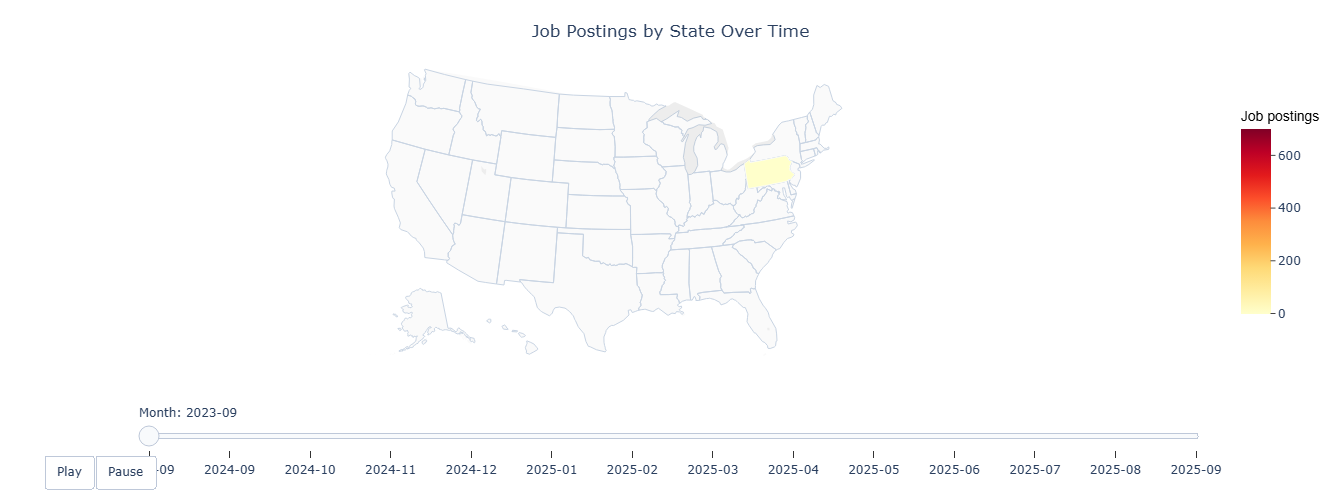

In [183]:
vmin = 0
vmax = np.nanmax(job_counts["job_count"].values)

fig = px.choropleth(
    job_counts,                 
    locations="state",           
    locationmode="USA-states",   
    color="job_count",         
    hover_name="state",          
    animation_frame="month",
    range_color=(vmin, vmax),
    color_continuous_scale="YlOrRd",
    labels={"job_count": "Job postings"},
    scope="usa"   # <-- added missing comma above
)

fig.update_traces(
    marker_line_color="white",
    marker_line_width=0.8,
    hovertemplate="<b>%{hovertext}</b><br>" +
                  "Month: %{animation_group}<br>" +
                  "Jobs: %{z:,}<extra></extra>"
)

fig.update_layout(
    title={
        "text": "Job Postings by State Over Time",
        "x": 0.5,
        "xanchor": "center",
        "y": 0.95
    },
    template="plotly_white",
    geo=dict(
        scope="usa",
        showlakes=True, lakecolor="rgba(0,0,0,0.05)",
        showcountries=False,
        showland=True, landcolor="rgba(0,0,0,0.02)"
    ),
    coloraxis_colorbar=dict(
    title=dict(text="Job postings", font=dict(size=14, family="Arial", color="black")),
    ticks="outside",
    tickformat=",",
    lenmode="fraction",
    len=0.75
)
,

    updatemenus=[{
        "type": "buttons",
        "showactive": False,
        "buttons": [
            {
                "label": "Play",
                "method": "animate",
                "args": [None, {"frame": {"duration": 700, "redraw": True},
                                "fromcurrent": True, "transition": {"duration": 300}}]
            },
            {
                "label": "Pause",
                "method": "animate",
                "args": [[None], {"frame": {"duration": 0, "redraw": False},
                                  "mode": "immediate",
                                  "transition": {"duration": 0}}]
            }
        ],
        "x": 0.02, "y": -0.08, "xanchor": "left", "yanchor": "top"
    }],
    sliders=[{
        "pad": {"t": 40},
        "currentvalue": {"prefix": "Month: "},
        "len": 0.9
    }]
)

fig.update_layout(
    width=1000,     
    height=500,    
    margin=dict(l=20, r=20, t=60, b=20)  
)


fig.layout.sliders[0].steps = sorted(fig.layout.sliders[0].steps, key=lambda s: s["label"])

fig.show()


## Employeement Type

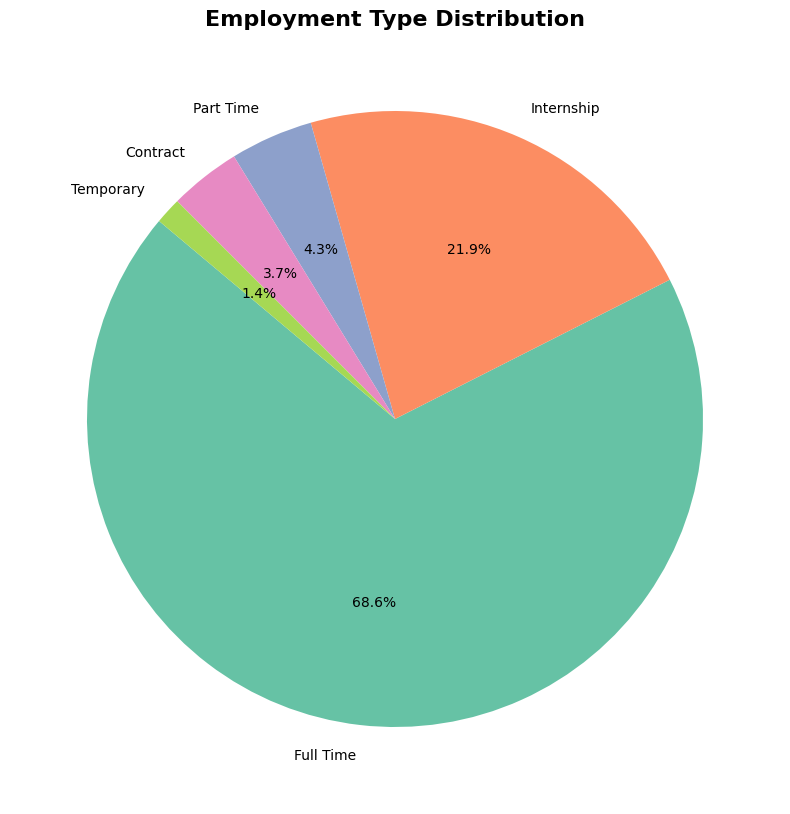

In [192]:
df["EmploymentType"] = df["EmploymentType"].replace({
    "Intern":"Internship",
    "Fulltime":"Full Time",
    "Contractor":"Contract"
})
emp_counts = df["EmploymentType"].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(
    emp_counts,
    labels=emp_counts.index,
    autopct="%.1f%%",
    startangle=140,
    colors=plt.cm.Set2.colors
)
plt.title("Employment Type Distribution", fontsize=16, fontweight="bold")
plt.show()

In [194]:
df.to_csv("Jobs_ML.csv", index = False)